Eğitim Başlatılıyor (cuda:0)...

--- Epoch 1/5 ---
Batch [200/1121] | Anlık Loss: 0.1513
Batch [400/1121] | Anlık Loss: 0.0566
Batch [600/1121] | Anlık Loss: 0.1988
Batch [800/1121] | Anlık Loss: 0.0994
Batch [1000/1121] | Anlık Loss: 0.0169
Batch [1121/1121] | Anlık Loss: 0.0162
Epoch 1 -> Train Loss: 0.1002 | Train Acc: 0.9625 | Val Acc: 0.9853
>> En iyi model kaydedildi: Acc = 0.9853

--- Epoch 2/5 ---
Batch [200/1121] | Anlık Loss: 0.0188
Batch [400/1121] | Anlık Loss: 0.0937
Batch [600/1121] | Anlık Loss: 0.0225
Batch [800/1121] | Anlık Loss: 0.0266
Batch [1000/1121] | Anlık Loss: 0.0099
Batch [1121/1121] | Anlık Loss: 0.1283
Epoch 2 -> Train Loss: 0.0539 | Train Acc: 0.9819 | Val Acc: 0.9894
>> En iyi model kaydedildi: Acc = 0.9894

--- Epoch 3/5 ---
Batch [200/1121] | Anlık Loss: 0.0815
Batch [400/1121] | Anlık Loss: 0.1213
Batch [600/1121] | Anlık Loss: 0.1678
Batch [800/1121] | Anlık Loss: 0.0250
Batch [1000/1121] | Anlık Loss: 0.0292
Batch [1121/1121] | Anlık Loss: 0.0416
Epo

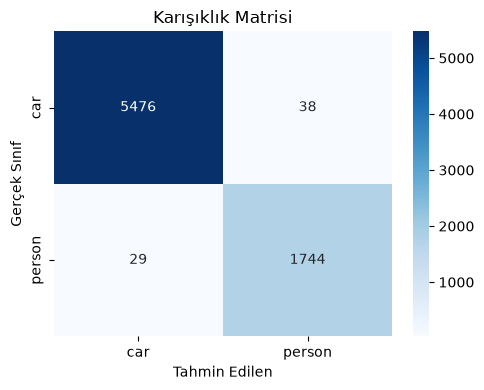

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
from src.dataset import get_dataloaders
from src.models import build_resnet18
from src.engine import train_model, evaluate_and_plot

# 1. Cihaz ve Veri
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
train_loader, val_loader, class_weights, class_names = get_dataloaders(data_dir="../dataset/raw", batch_size=32)

# 2. Model, Kayıp Fonksiyonu ve Optimizer
model = build_resnet18(num_classes=2, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# 3. Eğitim
SAVE_PATH = "../models/best_resnet18.pth"
train_model(model, train_loader, val_loader, criterion, optimizer, device, save_path=SAVE_PATH, epochs=5)

# 4. Değerlendirme
evaluate_and_plot(model, val_loader, class_names, device, weight_path=SAVE_PATH, cmap='Blues')